# Modèles Classiques de Détection de Fraude

Ce notebook entraîne et évalue plusieurs modèles classiques sur les données prétraitées.

In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# ── Chargement des données ────────────────────────────
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']
y_train        = data['y_train']
y_test         = data['y_test']

print(f"✅ Données chargées. Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

✅ Données chargées. Train: (1296675, 35), Test: (555719, 35)


In [2]:
def evaluate_model(model, X_test, y_test, name):
    """Fonction utilitaire pour évaluer un modèle et afficher la matrice de confusion"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Légitime', 'Fraude'])
    disp.plot(cmap='Blues')
    plt.title(f'Matrice de confusion - {name}')
    plt.show()


--- Régression Logistique ---
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    553574
           1       0.03      0.79      0.06      2145

    accuracy                           0.90    555719
   macro avg       0.51      0.84      0.50    555719
weighted avg       1.00      0.90      0.94    555719

AUC-ROC: 0.9408


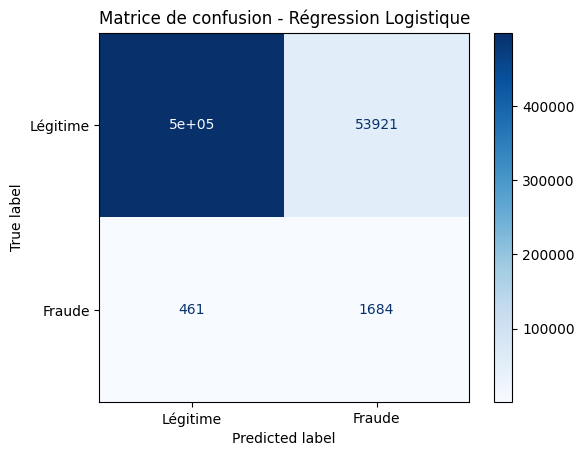

In [3]:
# ── Régression Logistique ─────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
evaluate_model(lr, X_test_scaled, y_test, "Régression Logistique")


--- Arbre de Décision ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.08      0.71      0.14      2145

    accuracy                           0.97    555719
   macro avg       0.54      0.84      0.56    555719
weighted avg       1.00      0.97      0.98    555719

AUC-ROC: 0.7668


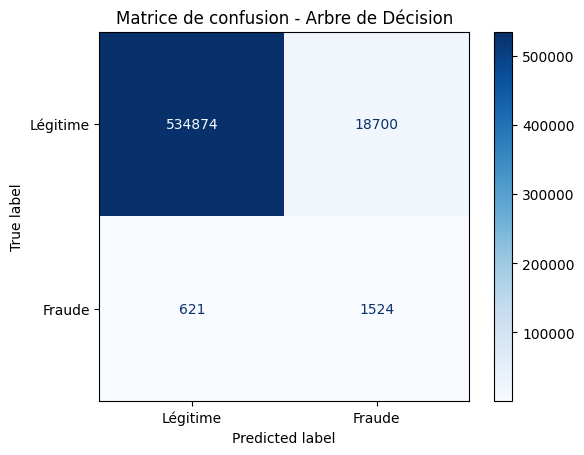


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.95      0.44      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.72      0.80    555719
weighted avg       1.00      1.00      1.00    555719

AUC-ROC: 0.9602


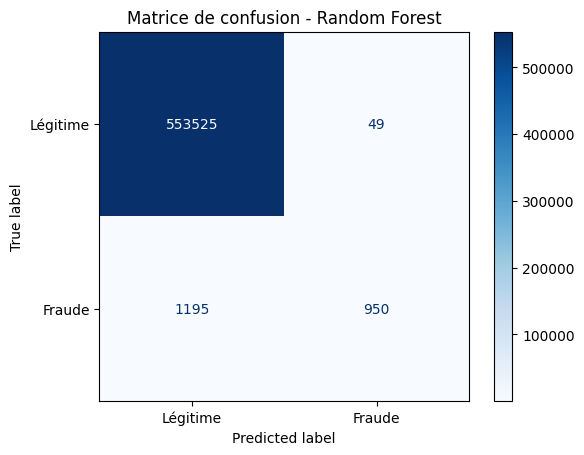

✅ Modèles classiques sauvegardés dans '../models/classical_models.pkl'


In [4]:
# ── Arbre de Décision ─────────────────────────────────
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
evaluate_model(dt, X_test_scaled, y_test, "Arbre de Décision")

# ── Random Forest ─────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             n_jobs=-1, random_state=42)
rf.fit(X_train_scaled, y_train)
evaluate_model(rf, X_test_scaled, y_test, "Random Forest")

# Sauvegarder les modèles pour le notebook d'évaluation
models_to_save = {
    'logistic_regression': lr,
    'decision_tree': dt,
    'random_forest': rf
}

with open('../models/classical_models.pkl', 'wb') as f:
    pickle.dump(models_to_save, f)
    
print("✅ Modèles classiques sauvegardés dans '../models/classical_models.pkl'")